# Full Persistent Memory RAG Pipeline [Step 3 - Load, Retrieve, Generate, Save]

> **MLCourse - Agentic AI - Persistent Memory RAG**

This notebook combines everything into a single LangGraph pipeline. At each
turn, the system: (1) loads the user's long-term memory, (2) rewrites the
query using conversation history, (3) retrieves relevant documents, (4) generates
an answer, and (5) saves the interaction to persistent memory. The graph is
visualized and every step is inspectable.

### What you will learn

1. Orchestrating memory, retrieval, and generation in a single graph
2. Loading and saving persistent user memory at each turn
3. History-aware query rewriting within a graph node
4. Graph visualization of the full pipeline
5. End-to-end multi-turn demo with memory inspection

### Sections

1. Setup
2. Load and index the document
3. Define persistent memory store
4. Define the graph state
5. Build graph nodes: load memory, rewrite, retrieve, generate, save
6. Define routing logic
7. Build and visualize the graph
8. End-to-end conversation demo
9. Memory inspection
10. Summary

In [1]:
from pathlib import Path
import os
import json
import re
import warnings
warnings.filterwarnings("ignore")

def _find_track(start_dir):
    here = Path(start_dir).resolve()
    for candidate in (here, *here.parents):
        if candidate.name == "03_agentic_ai":
            return candidate
        if (candidate / "03_agentic_ai").is_dir():
            return candidate / "03_agentic_ai"
    raise FileNotFoundError("Could not locate 03_agentic_ai near %s" % here)

TRACK = _find_track(Path.cwd())
DATA = TRACK / "data"
DATA.mkdir(parents=True, exist_ok=True)

from dotenv import load_dotenv
load_dotenv(TRACK / ".env", override=False)
load_dotenv(override=False)

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

print("track:", TRACK)
print("data :", DATA)

track: D:\projects\python\MLCourse\03_agentic_ai
data : D:\projects\python\MLCourse\03_agentic_ai\data


In [2]:
from langchain_ollama import ChatOllama, OllamaEmbeddings

llm = ChatOllama(model="llama3.1:8b", temperature=0)
LLM_LIVE = False
try:
    llm.invoke("Reply with the single word: pong")
    LLM_LIVE = True
    print("[GREEN] Ollama reachable, using llama3.1:8b")
except Exception as exc:
    print("[demo skipped] Ollama not reachable: %s" % type(exc).__name__)
    print("   start Ollama and run: ollama pull llama3.1:8b")
    print("   running with OFFLINE STUB model for this session")

[GREEN] Ollama reachable, using llama3.1:8b


In [3]:
# --- Section 2: load and index the document ------------------------------------
from langchain_text_splitters import CharacterTextSplitter
from langchain_chroma import Chroma

text_path = str(DATA / "alice.txt")
with open(text_path, "r", encoding="utf-8") as f:
    raw_text = f.read()

splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_text(raw_text)
print("Loaded alice.txt: %d chars -> %d chunks" % (len(raw_text), len(chunks)))

embeddings = OllamaEmbeddings(model="nomic-embed-text")
vectorstore = Chroma.from_texts(chunks, embeddings, collection_name="alice_persistent_rag")
print("Vector store built with %d vectors" % vectorstore._collection.count())

retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

Loaded alice.txt: 144696 chars -> 191 chunks


Vector store built with 191 vectors


In [4]:
# --- Section 3: define persistent memory store ---------------------------------
from langgraph.store.memory import InMemoryStore

memory_store = InMemoryStore()
print("Persistent memory store initialized.")

Persistent memory store initialized.


In [5]:
# --- Section 4: define the graph state -----------------------------------------
from typing import TypedDict, Annotated, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage

class PipelineState(TypedDict):
    messages: Annotated[list, add_messages]
    user_id: str
    user_memory: dict
    standalone_query: str
    retrieved_context: str
    answer: str
    is_followup: bool

print("PipelineState defined with %d fields." % len(PipelineState.__annotations__))

PipelineState defined with 7 fields.


In [6]:
# --- Section 5: build graph nodes ----------------------------------------------

# Node 1: Load persistent memory for this user
def load_memory(state: PipelineState, config) -> dict:
    """Read user profile and conversation facts from persistent store."""
    user_id = config["configurable"].get("user_id", "default")
    user_ns = ("rag_user", user_id)

    profile_item = memory_store.get(user_ns, "profile")
    facts_item = memory_store.get(user_ns, "facts")

    profile = profile_item.value if profile_item else {}
    facts = facts_item.value if facts_item else {}

    combined = {}
    combined.update(profile)
    if facts:
        combined["learned_facts"] = facts

    return {"user_memory": combined, "user_id": user_id}

# Node 2: Decide if this is a follow-up question
followup_prompt = None
if LLM_LIVE:
    from langchain_core.prompts import ChatPromptTemplate
    followup_prompt = ChatPromptTemplate.from_messages([
        ("system",
         "Determine if the user's latest message is a follow-up to previous "
         "conversation or a standalone question. "
         "Reply with ONLY 'followup' or 'standalone'."),
        ("user", "Previous messages:\n{history}\n\nLatest message: {question}")
    ])

def decide_followup(state: PipelineState, config) -> dict:
    """Node: decide if the question needs history context."""
    messages = state["messages"]
    if len(messages) <= 1:
        return {"is_followup": False}

    # Format previous messages
    history = ""
    for m in messages[:-1]:
        if hasattr(m, "type"):
            role = "User" if m.type == "human" else "Assistant"
            history += "%s: %s\n" % (role, m.content[:100])

    latest = messages[-1].content if messages else ""

    if LLM_LIVE and followup_prompt:
        response = llm.invoke(followup_prompt.format_messages(
            history=history, question=latest
        ))
        is_followup = "followup" in response.content.strip().lower()
    else:
        # Offline heuristic: if message is short and pronouns present
        pronouns = ["it", "he", "she", "they", "them", "that", "this", "those"]
        words = latest.lower().split()
        is_followup = any(w in pronouns for w in words) and len(words) < 10

    print("  [LOAD-MEMORY] user=%s, facts=%d" % (
        state.get("user_id", "?"),
        len(state.get("user_memory", {})),
    ))
    print("  [DECIDE] is_followup=%s" % is_followup)
    return {"is_followup": is_followup}

# Node 3: Rewrite query using history (only for follow-ups)
rewrite_prompt_template = None
if LLM_LIVE:
    rewrite_prompt_template = ChatPromptTemplate.from_messages([
        ("system",
         "Given a chat history and the latest user question, formulate a "
         "standalone question. Output ONLY the rewritten question."),
        ("user", "Chat history:\n{chat_history}\n\nLatest question: {question}")
    ])

def rewrite_query(state: PipelineState) -> dict:
    """Node: rewrite follow-up as standalone query."""
    messages = state["messages"]
    history_text = ""
    for m in messages[:-1]:
        if hasattr(m, "type"):
            role = "User" if m.type == "human" else "Assistant"
            history_text += "%s: %s\n" % (role, m.content[:100])

    question = messages[-1].content if messages else ""

    if LLM_LIVE and rewrite_prompt_template:
        response = llm.invoke(rewrite_prompt_template.format_messages(
            chat_history=history_text, question=question
        ))
        rewritten = response.content.strip()
    else:
        # Offline: pass through
        rewritten = question

    print("  [REWRITE] '%s' -> '%s'" % (question[:40], rewritten[:60]))
    return {"standalone_query": rewritten}

# Node 4: Retrieve documents
def retrieve_documents(state: PipelineState) -> dict:
    """Node: retrieve relevant documents from the vector store."""
    query = state.get("standalone_query") or state["messages"][-1].content
    docs = retriever.invoke(query)
    context = "\n\n---\n\n".join([d.page_content for d in docs])

    print("  [RETRIEVE] query='%s', docs=%d, chars=%d" % (
        query[:50], len(docs), len(context)))
    return {"retrieved_context": context}

# Node 5: Generate answer
rag_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are a helpful assistant answering questions about Alice in Wonderland. "
     "Use the provided context to answer. If the context is insufficient, "
     "say so. Be concise.\n\n"
     "User profile: {user_profile}\n\n"
     "Context:\n{context}"),
    ("user", "{question}")
])

def generate_answer(state: PipelineState) -> dict:
    """Node: generate an answer using context and user profile."""
    question = state["messages"][-1].content if state["messages"] else ""
    context = state.get("retrieved_context", "")
    user_profile = json.dumps(state.get("user_memory", {}))

    messages = rag_prompt.format_messages(
        user_profile=user_profile,
        context=context,
        question=question,
    )

    if LLM_LIVE:
        response = llm.invoke(messages)
        answer = response.content
    else:
        # Offline stub
        docs_preview = context[:120] if context else "(no docs)"
        answer = "[offline stub] Answering '%s' using %d chars of context." % (
            question[:30], len(context))
        if context:
            answer += "\nDoc preview: %s..." % docs_preview

    print("  [GENERATE] answer=%d chars" % len(answer))
    return {"answer": answer}

# Node 6: Save interaction to persistent memory
def save_memory(state: PipelineState, config) -> dict:
    """Node: save user facts and interaction summary to persistent store."""
    user_id = state.get("user_id", "default")
    user_ns = ("rag_user", user_id)

    # Extract facts from the latest user message
    last_user_msg = ""
    for m in reversed(state["messages"]):
        if hasattr(m, "type") and m.type == "human":
            last_user_msg = m.content
            break

    # Simple fact extraction
    new_facts = {}
    text_lower = last_user_msg.lower()
    if "my name is" in text_lower:
        match = re.search(r"my name is\s+(\w+)", text_lower)
        if match:
            new_facts["name"] = match.group(1).title()
    if "favorite" in text_lower:
        new_facts["recent_topic"] = last_user_msg[:80]
    if "tell me about" in text_lower:
        new_facts["last_query_topic"] = last_user_msg[:80]

    # Merge with existing facts
    existing = memory_store.get(user_ns, "facts")
    facts = existing.value if existing else {}
    facts.update(new_facts)

    # Track interaction count
    facts["interaction_count"] = facts.get("interaction_count", 0) + 1
    facts["last_question"] = last_user_msg[:100]

    memory_store.put(user_ns, "facts", facts)

    print("  [SAVE] user=%s, facts=%d, interactions=%d" % (
        user_id, len(facts), facts.get("interaction_count", 0)))
    return {}

In [7]:
# --- Section 6: build the graph ------------------------------------------------

graph_builder = StateGraph(PipelineState)

# Add nodes
graph_builder.add_node("load_memory", load_memory)
graph_builder.add_node("decide_followup", decide_followup)
graph_builder.add_node("rewrite_query", rewrite_query)
graph_builder.add_node("retrieve_documents", retrieve_documents)
graph_builder.add_node("generate_answer", generate_answer)
graph_builder.add_node("save_memory", save_memory)

# Entry point: always load memory first
graph_builder.add_edge(START, "load_memory")
graph_builder.add_edge("load_memory", "decide_followup")

# After deciding: rewrite if followup, otherwise retrieve directly
def route_after_decide(state: PipelineState) -> Literal["rewrite_query", "retrieve_documents"]:
    if state.get("is_followup"):
        return "rewrite_query"
    return "retrieve_documents"

graph_builder.add_conditional_edges(
    "decide_followup",
    route_after_decide,
    {
        "rewrite_query": "rewrite_query",
        "retrieve_documents": "retrieve_documents",
    },
)

# After rewrite, retrieve; after retrieve, generate; after generate, save
graph_builder.add_edge("rewrite_query", "retrieve_documents")
graph_builder.add_edge("retrieve_documents", "generate_answer")
graph_builder.add_edge("generate_answer", "save_memory")
graph_builder.add_edge("save_memory", END)

checkpointer = MemorySaver()
pipeline = graph_builder.compile(checkpointer=checkpointer, store=memory_store)
print("Persistent RAG pipeline compiled.")

Persistent RAG pipeline compiled.



=== Graph Visualization ===



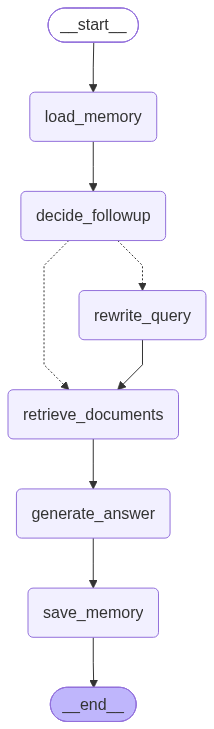

In [8]:
# --- Section 7: visualize the graph --------------------------------------------
print("\n=== Graph Visualization ===\n")

from IPython.display import Image, display
try:
    display(Image(pipeline.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization unavailable: %s" % e)
    print("Graph structure:")
    print("  START -> load_memory -> decide_followup")
    print("  decide_followup -> rewrite_query (if follow-up)")
    print("  decide_followup -> retrieve_documents (if standalone)")
    print("  rewrite_query -> retrieve_documents")
    print("  retrieve_documents -> generate_answer -> save_memory -> END")

In [9]:
# --- Section 8: end-to-end conversation demo ----------------------------------
print("=== End-to-End Persistent RAG Demo ===\n")

alice_config = {
    "configurable": {
        "thread_id": "alice-rag-s1",
        "user_id": "alice",
    }
}

# Turn 1: introduce yourself and ask a question
print("Turn 1: Introduce and ask about Alice")
print("-" * 40)
result = pipeline.invoke(
    {"messages": [("user", "Hi, my name is Alice. Tell me about Alice in Wonderland.")]},
    alice_config,
)
print("user: Hi, my name is Alice. Tell me about Alice in Wonderland.")
print("answer: %s" % result["answer"][:200])
print()

# Turn 2: follow-up question
print("Turn 2: Follow-up about the Queen")
print("-" * 40)
result = pipeline.invoke(
    {"messages": [("user", "What about the Queen of Hearts?")]},
    alice_config,
)
print("user: What about the Queen of Hearts?")
print("answer: %s" % result["answer"][:200])
print()

# Turn 3: another follow-up
print("Turn 3: Follow-up about how it ends")
print("-" * 40)
result = pipeline.invoke(
    {"messages": [("user", "How does the story end?")]},
    alice_config,
)
print("user: How does the story end?")
print("answer: %s" % result["answer"][:200])
print()

# Turn 4: standalone question
print("Turn 4: Standalone question")
print("-" * 40)
result = pipeline.invoke(
    {"messages": [("user", "Who wrote Alice in Wonderland?")]},
    alice_config,
)
print("user: Who wrote Alice in Wonderland?")
print("answer: %s" % result["answer"][:200])
print()

=== End-to-End Persistent RAG Demo ===

Turn 1: Introduce and ask about Alice
----------------------------------------
  [RETRIEVE] query='Hi, my name is Alice. Tell me about Alice in Wonde', docs=4, chars=3839


  [GENERATE] answer=536 chars
  [SAVE] user=alice, facts=4, interactions=1
user: Hi, my name is Alice. Tell me about Alice in Wonderland.
answer: You're the protagonist of the story! Alice's Adventures in Wonderland is a classic tale written by Lewis Carroll. It follows your adventures as you fall down a rabbit hole and enter a fantastical worl

Turn 2: Follow-up about the Queen
----------------------------------------


  [LOAD-MEMORY] user=alice, facts=1
  [DECIDE] is_followup=True


  [REWRITE] 'What about the Queen of Hearts?' -> 'What do we know about the Queen of Hearts from the story of '
  [RETRIEVE] query='What do we know about the Queen of Hearts from the', docs=4, chars=3607


  [GENERATE] answer=902 chars
  [SAVE] user=alice, facts=4, interactions=2
user: What about the Queen of Hearts?
answer: The Queen of Hearts is a central character in this passage from Alice's Adventures in Wonderland. She appears to be a tyrannical and temperamental ruler who is prone to outbursts of anger and violence

Turn 3: Follow-up about how it ends
----------------------------------------


  [LOAD-MEMORY] user=alice, facts=1
  [DECIDE] is_followup=True


  [REWRITE] 'How does the story end?' -> 'How does the story of Alice in Wonderland conclude?'
  [RETRIEVE] query='How does the story of Alice in Wonderland conclude', docs=4, chars=3610


  [GENERATE] answer=217 chars
  [SAVE] user=alice, facts=4, interactions=3
user: How does the story end?
answer: The provided context only includes the first few chapters of "Alice's Adventures in Wonderland" by Lewis Carroll. The ending is not included in this snippet. I would need more information to provide a

Turn 4: Standalone question
----------------------------------------


  [LOAD-MEMORY] user=alice, facts=1
  [DECIDE] is_followup=False
  [RETRIEVE] query='How does the story of Alice in Wonderland conclude', docs=4, chars=3610


  [GENERATE] answer=74 chars
  [SAVE] user=alice, facts=4, interactions=4
user: Who wrote Alice in Wonderland?
answer: The story "Alice's Adventures in Wonderland" was written by Lewis Carroll.



In [10]:
# --- Section 9: memory inspection ---------------------------------------------
print("=== Persistent Memory Inspection ===\n")

alice_ns = ("rag_user", "alice")
facts = memory_store.get(alice_ns, "facts")
print("Alice's stored facts:")
if facts:
    print(json.dumps(facts.value, indent=2))
else:
    print("  (none)")

# Verify across a new thread
print("\n--- New thread, same user ---")
alice_config_new = {
    "configurable": {
        "thread_id": "alice-rag-s2",    # new thread
        "user_id": "alice",              # same user
    }
}

result = pipeline.invoke(
    {"messages": [("user", "Do you remember what I asked about before?")]},
    alice_config_new,
)
print("user: Do you remember what I asked about before?")
print("answer: %s" % result["answer"][:200])
print()

# Re-check facts after the new interaction
facts_after = memory_store.get(alice_ns, "facts")
print("Alice's facts after new thread:")
if facts_after:
    print(json.dumps(facts_after.value, indent=2))

=== Persistent Memory Inspection ===

Alice's stored facts:
{
  "name": "Alice",
  "last_query_topic": "Hi, my name is Alice. Tell me about Alice in Wonderland.",
  "interaction_count": 4,
  "last_question": "Who wrote Alice in Wonderland?"
}

--- New thread, same user ---
  [RETRIEVE] query='Do you remember what I asked about before?', docs=4, chars=3925


  [GENERATE] answer=132 chars
  [SAVE] user=alice, facts=4, interactions=5
user: Do you remember what I asked about before?
answer: You're Alice! Your last question was "Who wrote Alice in Wonderland?" and I'm happy to help with any new questions you may have now!

Alice's facts after new thread:
{
  "name": "Alice",
  "last_query_topic": "Hi, my name is Alice. Tell me about Alice in Wonderland.",
  "interaction_count": 5,
  "last_question": "Do you remember what I asked about before?"
}


In [11]:
# --- Section 10: second user isolation ----------------------------------------
print("\n=== User Isolation in Persistent RAG ===\n")

bob_config = {
    "configurable": {
        "thread_id": "bob-rag-s1",
        "user_id": "bob",
    }
}

result = pipeline.invoke(
    {"messages": [("user", "My name is Bob. Tell me about the Cheshire Cat.")]},
    bob_config,
)
print("user (Bob): My name is Bob. Tell me about the Cheshire Cat.")
print("answer: %s" % result["answer"][:200])
print()

# Check both users' memory
alice_facts = memory_store.get(("rag_user", "alice"), "facts")
bob_facts = memory_store.get(("rag_user", "bob"), "facts")
print("Alice facts:", json.dumps(alice_facts.value, indent=2) if alice_facts else "None")
print("Bob facts  :", json.dumps(bob_facts.value, indent=2) if bob_facts else "None")


=== User Isolation in Persistent RAG ===



  [RETRIEVE] query='My name is Bob. Tell me about the Cheshire Cat.', docs=4, chars=3470


  [GENERATE] answer=639 chars
  [SAVE] user=bob, facts=4, interactions=1
user (Bob): My name is Bob. Tell me about the Cheshire Cat.
answer: The Cheshire Cat! He's a rather peculiar and mysterious creature, Bob. He has very long claws and many teeth, which can be intimidating at first. However, he seems to have a good-natured personality, 

Alice facts: {
  "name": "Alice",
  "last_query_topic": "Hi, my name is Alice. Tell me about Alice in Wonderland.",
  "interaction_count": 5,
  "last_question": "Do you remember what I asked about before?"
}
Bob facts  : {
  "name": "Bob",
  "last_query_topic": "My name is Bob. Tell me about the Cheshire Cat.",
  "interaction_count": 1,
  "last_question": "My name is Bob. Tell me about the Cheshire Cat."
}


In [12]:
# --- Summary -------------------------------------------------------------------
print("\n" + "=" * 60)
print("Persistent Memory RAG Pipeline Summary:")
print("  Pipeline: load_memory -> decide -> [rewrite] -> retrieve -> generate -> save")
print("  Memory: InMemoryStore with per-user namespaces")
print("  Follow-up detection: rewrites queries using conversation history")
print("  Persistent facts: user info and interaction history survive across threads")
print("  User isolation: alice and bob have completely separate memory namespaces")
print("  Production: swap InMemoryStore for Redis or database-backed store")
print("  Combine: MemorySaver (per-thread) + InMemoryStore (cross-thread)")
print("=" * 60)


Persistent Memory RAG Pipeline Summary:
  Pipeline: load_memory -> decide -> [rewrite] -> retrieve -> generate -> save
  Memory: InMemoryStore with per-user namespaces
  Follow-up detection: rewrites queries using conversation history
  Persistent facts: user info and interaction history survive across threads
  User isolation: alice and bob have completely separate memory namespaces
  Production: swap InMemoryStore for Redis or database-backed store
  Combine: MemorySaver (per-thread) + InMemoryStore (cross-thread)
